<a href="https://colab.research.google.com/github/4Y4GX/image-classification-cnn-rf-svm/blob/main/image_classification_cnn_rf_svm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
import numpy as np
import json
import joblib
import pickle
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os
import numpy as np
import json
import joblib
import pickle
import matplotlib.pyplot as plt
import seaborn as sns

# ============================
# Load Dataset
# ============================
def load_data(google_drive_base_dir, img_height=128, img_width=128, batch_size=32):
    train_dir = os.path.join(google_drive_base_dir, "train")
    test_dir = os.path.join(google_drive_base_dir, "test")

    train_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

    train_data = train_datagen.flow_from_directory(
        train_dir, target_size=(img_height, img_width),
        batch_size=batch_size, subset="training", class_mode="categorical"
    )
    val_data = train_datagen.flow_from_directory(
        train_dir, target_size=(img_height, img_width),
        batch_size=batch_size, subset="validation", class_mode="categorical"
    )

    test_datagen = ImageDataGenerator(rescale=1./255)
    test_data = test_datagen.flow_from_directory(
        test_dir, target_size=(img_height, img_width),
        batch_size=batch_size, class_mode="categorical", shuffle=False
    )

    return train_data, val_data, test_data

In [16]:
# Check if the directory exists
import os

google_drive_dataset_path = "/content/drive/MyDrive/human_facial_expression_dataset/Dataset(Final)"
train_dir_check = os.path.join(google_drive_dataset_path, "train")

if os.path.exists(train_dir_check):
    print(f"The directory '{train_dir_check}' exists.")
else:
    print(f"The directory '{train_dir_check}' does not exist. Please check the path or ensure Google Drive is mounted correctly.")

The directory '/content/drive/MyDrive/human_facial_expression_dataset/Dataset(Final)/train' exists.


In [17]:
# ============================
# Evaluation Helpers
# ============================
def evaluate_model(y_true, y_pred, class_names, model_name="Model"):
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average="weighted")

    print(f"\n✅ {model_name} Accuracy: {acc:.4f}")
    print(f"✅ {model_name} F1 Score: {f1:.4f}")

    print(f"\n{model_name} Classification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names,
                yticklabels=class_names)
    plt.title(f"{model_name} Confusion Matrix")
    plt.show()

    return acc, f1

In [25]:
import os, json, pickle
import numpy as np
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

def train_cnn(train_data, val_data, test_data, save_dir="models"):
    img_height, img_width = 128, 128

    # CNN model
    cnn_model = Sequential([
        Conv2D(32, (3,3), activation='relu', input_shape=(img_height, img_width, 3)),
        MaxPooling2D(2,2),
        Conv2D(64, (3,3), activation='relu'),
        MaxPooling2D(2,2),
        Conv2D(128, (3,3), activation='relu'),
        MaxPooling2D(2,2),
        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(train_data.num_classes, activation='softmax')
    ])

    cnn_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    history = cnn_model.fit(train_data, validation_data=val_data, epochs=10)

    # Evaluate on test
    y_true = test_data.classes
    y_pred = np.argmax(cnn_model.predict(test_data), axis=1)
    acc, f1 = evaluate_model(y_true, y_pred, list(test_data.class_indices.keys()), "CNN")

    # Save
    os.makedirs(save_dir, exist_ok=True)
    cnn_model.save(f"{save_dir}/cnn_emotion_model.keras") # Changed .h5 to .keras

    with open(f"{save_dir}/training_history.pkl", "wb") as f:
        pickle.dump(history.history, f)

    with open(f"{save_dir}/class_indices.json", "w") as f:
        json.dump({v: k for k, v in train_data.class_indices.items()}, f)

    return acc, f1

In [19]:
import os
import numpy as np
import joblib
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

def train_rf(train_data, save_dir="models"):
    # Feature extraction
    X, y = [], []
    for images, labels in train_data:
        for i in range(images.shape[0]):
            X.append(images[i].flatten())
            y.append(np.argmax(labels[i]))
        if len(X) > 2000:  # limit for speed
            break

    X, y = np.array(X), np.array(y)
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

    rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
    rf_model.fit(X_train, y_train)

    y_pred = rf_model.predict(X_val)
    acc, f1 = evaluate_model(y_val, y_pred, list(train_data.class_indices.keys()), "Random Forest")

    # Save
    os.makedirs(save_dir, exist_ok=True)
    joblib.dump(rf_model, f"{save_dir}/rf_emotion_model.pkl")

    return acc, f1

In [20]:
import os
import numpy as np
import joblib
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
#from utils import evaluate_model

def train_svm(train_data, save_dir="models"):
    # Feature extraction
    X, y = [], []
    for images, labels in train_data:
        for i in range(images.shape[0]):
            X.append(images[i].flatten())
            y.append(np.argmax(labels[i]))
        if len(X) > 2000:  # limit for speed
            break

    X, y = np.array(X), np.array(y)
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

    svm_model = SVC(kernel="linear", probability=True, random_state=42)
    svm_model.fit(X_train, y_train)

    y_pred = svm_model.predict(X_val)
    acc, f1 = evaluate_model(y_val, y_pred, list(train_data.class_indices.keys()), "SVM")

    # Save
    os.makedirs(save_dir, exist_ok=True)
    joblib.dump(svm_model, f"{save_dir}/svm_emotion_model.pkl")

    return acc, f1

In [21]:
import os
import numpy as np
import joblib
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split

def train_svm(train_data, save_dir="models"):
    # Feature extraction
    X, y = [], []
    for images, labels in train_data:
        for i in range(images.shape[0]):
            X.append(images[i].flatten())
            y.append(np.argmax(labels[i]))
        if len(X) > 2000:  # limit for speed
            break

    X, y = np.array(X), np.array(y)
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

    svm_model = SVC(kernel="linear", probability=True, random_state=42)
    svm_model.fit(X_train, y_train)

    y_pred = svm_model.predict(X_val)
    acc, f1 = evaluate_model(y_val, y_pred, list(train_data.class_indices.keys()), "SVM")

    # Save
    os.makedirs(save_dir, exist_ok=True)
    joblib.dump(svm_model, f"{save_dir}/svm_emotion_model.pkl")

    return acc, f1

Found 1157 images belonging to 5 classes.
Found 286 images belonging to 5 classes.
Found 181 images belonging to 5 classes.

--- Training CNN ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 373s 10s/step - accuracy: 0.2241 - loss: 1.6443 - val_accuracy: 0.5874 - val_loss: 1.2283
Epoch 2/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 48s 1s/step - accuracy: 0.5492 - loss: 1.2014 - val_accuracy: 0.6853 - val_loss: 0.8752
Epoch 3/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 48s 1s/step - accuracy: 0.6936 - loss: 0.8570 - val_accuracy: 0.7657 - val_loss: 0.7132
Epoch 4/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 48s 1s/step - accuracy: 0.7332 - loss: 0.7055 - val_accuracy: 0.7692 - val_loss: 0.6237
Epoch 5/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 48s 1s/step - accuracy: 0.7368 - loss: 0.6966 - val_accuracy: 0.7727 - val_loss: 0.6304
Epoch 6/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 48s 1s/step - accuracy: 0.7707 - loss: 0.6012 - val_accuracy: 0.7622 - val_loss: 0.5723
Epoch 7/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 48s 1s/step - accuracy: 0.7629 - loss: 0.5673 - val_accuracy: 0.7692 - val_loss: 0.6395
Epoch 8/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 48s 1s/step - accuracy: 0.8273 - loss: 0.4723 - val_accuracy: 0.7902 - val_los

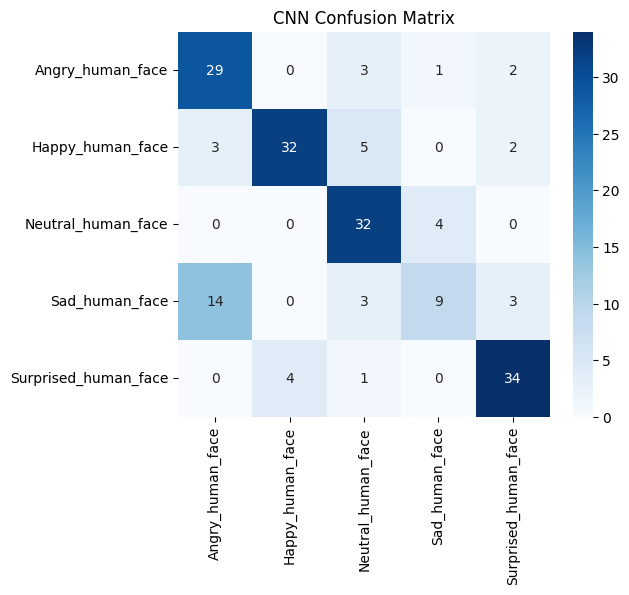


--- Training Random Forest ---

✅ Random Forest Accuracy: 0.8519
✅ Random Forest F1 Score: 0.8494

Random Forest Classification Report:
                      precision    recall  f1-score   support

    Angry_human_face       0.74      0.80      0.77        79
    Happy_human_face       0.89      0.93      0.91        89
  Neutral_human_face       0.90      0.92      0.91        78
      Sad_human_face       0.75      0.62      0.68        68
Surprised_human_face       0.93      0.93      0.93        91

            accuracy                           0.85       405
           macro avg       0.84      0.84      0.84       405
        weighted avg       0.85      0.85      0.85       405



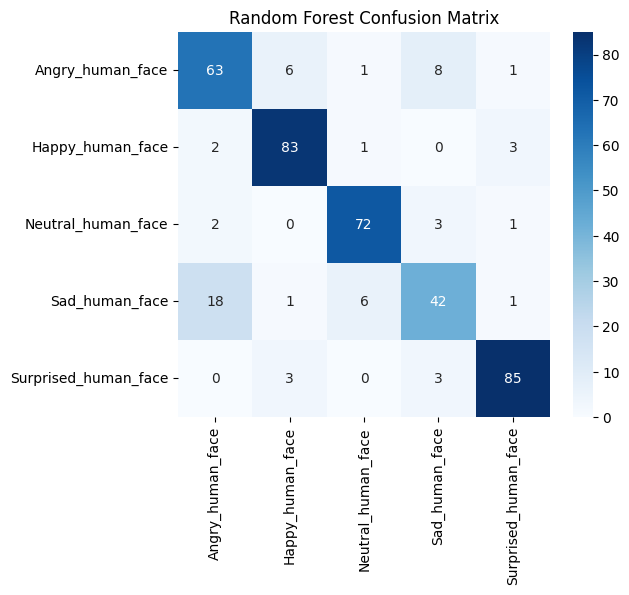


--- Training SVM ---

✅ SVM Accuracy: 0.8448
✅ SVM F1 Score: 0.8424

SVM Classification Report:
                      precision    recall  f1-score   support

    Angry_human_face       0.80      0.76      0.78        85
    Happy_human_face       0.90      0.90      0.90        89
  Neutral_human_face       0.82      0.99      0.90        75
      Sad_human_face       0.78      0.68      0.73        76
Surprised_human_face       0.91      0.89      0.90        81

            accuracy                           0.84       406
           macro avg       0.84      0.84      0.84       406
        weighted avg       0.84      0.84      0.84       406



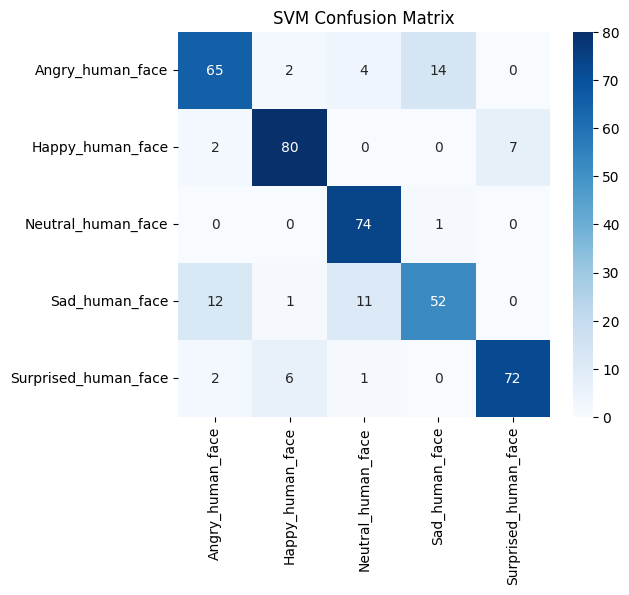


=== Final Results ===
CNN Accuracy: 0.7514, F1: 0.7382
Random Forest Accuracy: 0.8519, F1: 0.8494
SVM Accuracy: 0.8448, F1: 0.8424


In [22]:
# Corrected path to the dataset in Google Drive
google_drive_dataset_path = "/content/drive/MyDrive/human_facial_expression_dataset/Dataset(Final)"
google_drive_models_path = "/content/drive/MyDrive/emotion_models" # Define the path for saving models in Google Drive

# Load data
train_data, val_data, test_data = load_data(google_drive_dataset_path)

# Train & Evaluate models

# --- CNN ---
print("\n--- Training CNN ---")
cnn_acc, cnn_f1 = train_cnn(train_data, val_data, test_data, save_dir=google_drive_models_path) # Pass the Google Drive path

# --- Random Forest ---
print("\n--- Training Random Forest ---")
rf_acc, rf_f1 = train_rf(train_data, save_dir=google_drive_models_path) # Pass the Google Drive path

# --- SVM ---
print("\n--- Training SVM ---")
svm_acc, svm_f1 = train_svm(train_data, save_dir=google_drive_models_path) # Pass the Google Drive path

# ============================
# Final Comparison
# ============================
print("\n=== Final Results ===")
print(f"CNN Accuracy: {cnn_acc:.4f}, F1: {cnn_f1:.4f}")
print(f"Random Forest Accuracy: {rf_acc:.4f}, F1: {rf_f1:.4f}")
print(f"SVM Accuracy: {svm_acc:.4f}, F1: {svm_f1:.4f}")

In [24]:
from google.colab import drive
import os

# Check if Google Drive is already mounted
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')
else:
    print("Google Drive is already mounted.")

Google Drive is already mounted.
